# KKBox Churn Prediction — EDA

Explores the parquet files in `data/processed/` (see `00_data_processing.ipynb`). Uses `duckdb` to query directly against parquet on disk so the 392M-row `user_logs.parquet` (6.4GB) never needs to be loaded fully into pandas memory.

In [1]:
import os

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
con = duckdb.connect()


def p(name):
    return os.path.join(PROCESSED_DIR, f"{name}.parquet")


sns.set_theme(style="whitegrid")

## Dataset overview

Row counts per table (instant — read from parquet metadata, no data scan).

In [2]:
for name in ["members", "train", "train_v2", "transactions", "transactions_v2", "user_logs_v2", "user_logs"]:
    n = con.execute(f"select count(*) from '{p(name)}'").fetchone()[0]
    print(f"{name:20s} {n:>15,} rows")

members                    6,769,473 rows
train                        992,931 rows
train_v2                     970,960 rows
transactions              21,547,746 rows
transactions_v2            1,431,009 rows
user_logs_v2              18,396,362 rows
user_logs                392,106,543 rows


## Churn label balance (`train_v2`)

This is the target we'd model. It's imbalanced: **~9% churn** vs ~91% retained, so downstream modeling should account for the imbalance (class weights, stratified sampling, or a metric like AUC/PR-AUC rather than accuracy).

,is_churn,n,pct
0,0,883630,91.005809
1,1,87330,8.994191


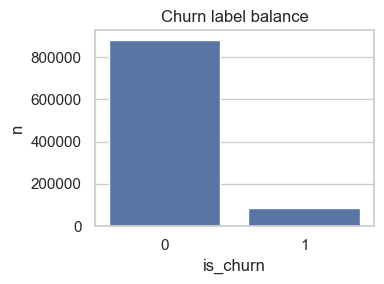

In [3]:
churn_balance = con.execute(f"select is_churn, count(*) n from '{p('train_v2')}' group by 1 order by 1").df()
churn_balance["pct"] = churn_balance["n"] / churn_balance["n"].sum() * 100
display(churn_balance)

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(data=churn_balance, x="is_churn", y="n", ax=ax)
ax.set_title("Churn label balance")
fig.tight_layout()

## Member demographics

`members` is small enough (6.8M rows) to load fully into pandas.

**Data quality issue:** `bd` (age) is self-reported and mostly garbage — only **~33%** of values fall in a plausible 1-100 range (min/max seen are -7168 and 2016). Any modeling use of age should filter to that range and treat the rest as missing.

valid bd share: 32.8%


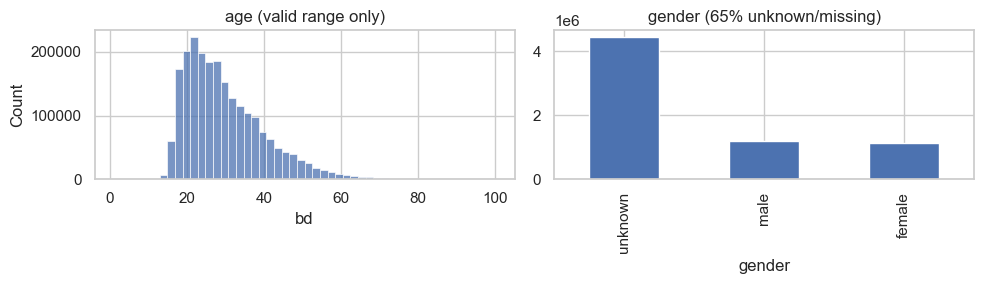

In [4]:
members = con.execute(f"select city, bd, gender, registered_via, registration_init_time from '{p('members')}'").df()
valid_bd = members[(members.bd > 0) & (members.bd <= 100)]
print(f"valid bd share: {len(valid_bd) / len(members) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(valid_bd["bd"], bins=50, ax=axes[0])
axes[0].set_title("age (valid range only)")
members["gender"].fillna("unknown").value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("gender (65% unknown/missing)")
fig.tight_layout()

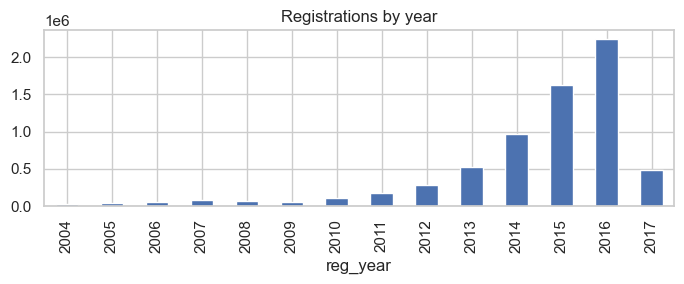

In [5]:
members["reg_year"] = members["registration_init_time"].astype(str).str[:4].astype(int)

fig, ax = plt.subplots(figsize=(7, 3))
members[members.reg_year.between(2004, 2017)]["reg_year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Registrations by year")
fig.tight_layout()

## Churn rate by member attributes

Joining `train_v2` with `members`. Notable patterns:
- `registered_via` matters a lot: channel 4 churns at **23%**, channel 3 at **17%**, vs channel 7 at only **4.5%**.
- Users with missing gender/age (the majority) churn noticeably *less* (~6%) than users with a recorded gender/age (~13-18%) — the presence of profile data may itself be a signal of engagement, or these could be different user cohorts (e.g. signup era/channel).
- Among valid ages, the youngest bucket (1-17, mostly likely still low-quality data) has the highest churn (~28%), and 18-24 is also high (~18%).

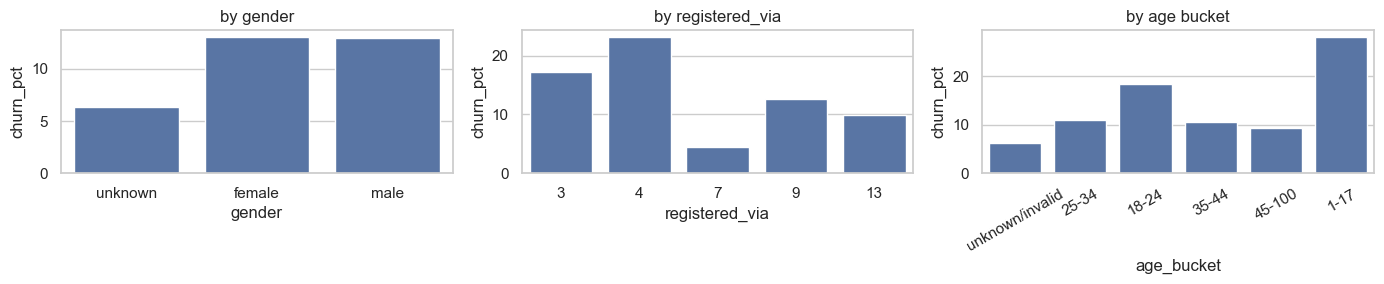

In [6]:
churn_by_gender = con.execute(f"""
    select coalesce(m.gender, 'unknown') gender, count(*) n, avg(t.is_churn) * 100 churn_pct
    from '{p('train_v2')}' t
    left join '{p('members')}' m using (msno)
    group by 1
""").df()

churn_by_registered_via = con.execute(f"""
    select m.registered_via, count(*) n, avg(t.is_churn) * 100 churn_pct
    from '{p('train_v2')}' t
    left join '{p('members')}' m using (msno)
    group by 1 order by n desc limit 8
""").df()

churn_by_age = con.execute(f"""
    select case when m.bd between 1 and 17 then '1-17'
                when m.bd between 18 and 24 then '18-24'
                when m.bd between 25 and 34 then '25-34'
                when m.bd between 35 and 44 then '35-44'
                when m.bd between 45 and 100 then '45-100'
                else 'unknown/invalid' end age_bucket,
           count(*) n, avg(t.is_churn) * 100 churn_pct
    from '{p('train_v2')}' t
    left join '{p('members')}' m using (msno)
    group by 1 order by n desc
""").df()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
sns.barplot(data=churn_by_gender, x="gender", y="churn_pct", ax=axes[0])
sns.barplot(data=churn_by_registered_via, x="registered_via", y="churn_pct", ax=axes[1])
sns.barplot(data=churn_by_age, x="age_bucket", y="churn_pct", ax=axes[2])
axes[2].tick_params(axis="x", rotation=30)
for ax, title in zip(axes, ["by gender", "by registered_via", "by age bucket"]):
    ax.set_title(title)
fig.tight_layout()

## Subscription / transaction behavior (`transactions_v2`)

`transactions_v2` covers the same window as the `train_v2` labels. Taking each user's latest transaction and joining to churn shows the strongest signals in the whole dataset:
- **`is_auto_renew=0`**: 30.6% churn vs 1.8% for `is_auto_renew=1` — auto-renew is a very strong retention signal.
- **`is_cancel=1`**: 79.0% churn vs 4.4% for `is_cancel=0` — a cancellation almost always precedes churn (expected, borderline definitional — worth checking for label leakage if used directly as a model feature).
- Plans with `payment_plan_days > 90` churn at 90-99%, vs ~4.4% for the dominant 1-31 day plans — these longer/unusual plans are rare and behave very differently.

,is_auto_renew,is_cancel,n,churn_pct
0,0,0,82918,30.579609
1,1,0,827985,1.765370
2,1,1,22675,79.038589


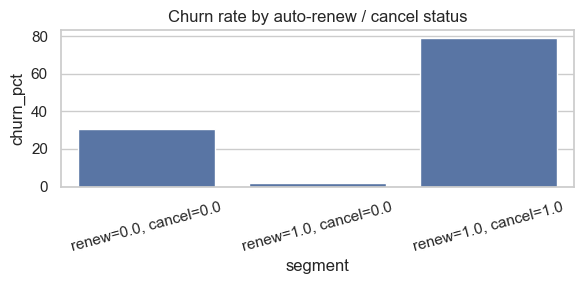

In [7]:
txn_behavior = con.execute(f"""
    with latest as (
        select *, row_number() over (partition by msno order by transaction_date desc) rn
        from '{p('transactions_v2')}'
    )
    select l.is_auto_renew, l.is_cancel, count(*) n, avg(t.is_churn) * 100 churn_pct
    from latest l
    join '{p('train_v2')}' t using (msno)
    where l.rn = 1
    group by 1, 2
    order by 1, 2
""").df()
display(txn_behavior)

txn_behavior["segment"] = txn_behavior.apply(lambda r: f"renew={r.is_auto_renew}, cancel={r.is_cancel}", axis=1)
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=txn_behavior, x="segment", y="churn_pct", ax=ax)
ax.set_title("Churn rate by auto-renew / cancel status")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()

## Listening behavior (`user_logs_v2`) vs churn

Aggregating daily logs per user over the `train_v2` window. Churned users show **modestly lower** engagement (18.1 vs 15.9 active days, 39.2 vs 35.1 total hours) — a real but much weaker signal than the subscription/renewal features above. Also notable: **22%** of `train_v2` users have zero rows in `user_logs_v2` at all (no logged listening activity in that window).

In [8]:
behavior_vs_churn = con.execute(f"""
    with agg as (
        select msno, count(distinct date) active_days, sum(total_secs) / 3600 total_hours, sum(num_unq) total_unq
        from '{p('user_logs_v2')}'
        group by msno
    )
    select t.is_churn, count(*) n, avg(a.active_days) avg_active_days,
           avg(a.total_hours) avg_total_hours, avg(a.total_unq) avg_unq_songs
    from '{p('train_v2')}' t
    left join agg a using (msno)
    group by 1
""").df()
display(behavior_vs_churn)

pct_no_activity = con.execute(f"""
    select avg(case when a.msno is null then 1 else 0 end) * 100
    from '{p('train_v2')}' t
    left join (select distinct msno from '{p('user_logs_v2')}') a using (msno)
""").fetchone()[0]
print(f"train_v2 users with zero user_logs_v2 rows: {pct_no_activity:.1f}%")

,is_churn,n,avg_active_days,avg_total_hours,avg_unq_songs
0,0,883630,18.134032,39.198078,515.732526
1,1,87330,15.914814,35.080897,472.744190


train_v2 users with zero user_logs_v2 rows: 22.3%


## Scanning the full `user_logs` history at scale

`user_logs.parquet` covers 2015-01-01 through 2017-02-28 across 5.2M users in 392M rows. duckdb aggregates it directly off disk in a few seconds without loading it into pandas.

**Data quality issue:** `total_secs` has corrupted extreme values in a small fraction of rows — min/max are around ±9.2e15 (looks like an int64 sentinel/overflow artifact from the original data pipeline), and ~62K rows are negative / ~143K rows exceed 86,400 seconds (a day) out of 392M total (~0.05%). Any per-user aggregation of `total_secs` should clip or filter these before use.

In [9]:
scale_overview = con.execute(f"""
    select min(date) min_date, max(date) max_date, count(distinct msno) n_users, count(*) n_rows
    from '{p('user_logs')}'
""").df()
display(scale_overview)

bad_secs = con.execute(f"""
    select min(total_secs), max(total_secs),
           sum(case when total_secs < 0 then 1 else 0 end) n_negative,
           sum(case when total_secs > 86400 then 1 else 0 end) n_over_a_day,
           count(*) n_total
    from '{p('user_logs')}'
""").df()
display(bad_secs)

,min_date,max_date,n_users,n_rows
0,20150101,20170228,5234111,392106543


,min(total_secs),max(total_secs),n_negative,n_over_a_day,n_total
0,-9.223372e+15,9.223372e+15,61493.0,142993.0,392106543


## Key takeaways

- **Class imbalance**: ~9% churn rate — use stratified splits and an imbalance-aware metric/loss for modeling.
- **Strongest signals** are subscription-behavior features: `is_auto_renew` and `is_cancel` from the latest transaction dominate everything else (30.6% vs 1.8% churn, 79.0% vs 4.4% churn respectively). Treat `is_cancel` carefully — it may be too close to the churn definition to use as a naive feature.
- **Listening activity** (`user_logs`) is a real but weaker signal — churned users log modestly fewer active days and hours. 22% of labeled users have no logged activity at all in the final window.
- **Demographics** (`registered_via`, age, gender) show real variation (e.g. `registered_via=4` churns at 23% vs 4.5% for `registered_via=7`) but most `bd`/`gender` values are missing or garbage and need cleaning before use.
- **Data quality**: `bd` (age) is valid for only ~33% of members; `total_secs` in `user_logs` has rare but extreme corrupted values that need clipping.